# Train world model

**The 8500 freeze is Jupyter, not CUDA.** After writing
`results/m3/recon_step_08500.png`, `clear_output(wait=True)` blocked the
kernel until the notebook UI finished rendering. GPU sat idle (~1%) with
VRAM still allocated, so the cell looked "running" with a stuck dashboard.

1. **Kernel → Interrupt.** If that works, the in-memory model is at 8500 —
   run `torch.save({"step": 8500, "model": model.state_dict(), "optim": optim.state_dict()}, Path("checkpoints/m3_world_model/ckpt_step_08500.pt"))` then set `RESUME` to that path.
2. If Interrupt does nothing, **Restart** and resume
   `checkpoints/m3_world_model/ckpt_step_08000.pt` (lose 8001–8500).

`grad=0.0000` on the status line is `grad_scale=0` (that loss term is
off), not vanished parameter gradients. `free_nats` is **1.0**.

Textures and the full inventory bar died at `d19b279` (`recon_blob_scale=5`)
plus live `[h,z]` decoder weights:

1. **`recon_blob` is 7px tile-mean L1.** Same scale as full-frame recon.
   Optimum is one color per Crafter tile — solid blue/green, no grass
   dithering, no HUD icon texture. **Off.**
2. **`[h,z]` is a 4×4 map.** Training the upsample on it teaches 16×16
   solid cells. Decoder weights are frozen on that paint again; only
   embed (the encoder's 4×4) trains texture and the full inventory strip.

Two things in the last architecture were flattening the image:

1. **Pasted HUD head.** A second decoder painted rows 49–63 and overwrote
   whatever the 64×64 upsample had learned for the inventory. That head
   starts near black, so the bar stayed black. Gone — one upsample paints
   the whole frame, including the bar.
2. **Frozen decoder weights on `[h,z]`.** Only the embed path could train
   the renderer. Live weights again; per-cell `z` still stops layout scramble.

`recon_avatar_scale` / `recon_hud_scale` are 0. `recon_blob` stays on.

## Why sprites / HUD / cows never showed up

Two separate bugs, in order:

1. **U-Net skip-to-RGB on the world-model graph** (fixed last run). The
   dashboard copied the real frame; RSSM never saw that content.
2. **The skip-free encoder was not DreamerV3's CNN.** Ours was one stride-2
   conv per octave. DreamerV3's `ImageEncoderResnet` downsamples, then runs
   **residual 3x3 blocks at 32 / 16 / 8 / 4** (`cnn_blocks=2`) so an 8–12px
   cow can become a feature *before* it is flattened to 4x4. Without those
   blocks, small objects are averaged into grass. That is why `[h,z]` and
   embed both stayed cow-less / HUD-blank no matter the loss knobs.

3. **Posterior mixing Linear.** Encoder flatten is a 4×4 map (`12288 =
   768×4×4`). The RSSM was `Linear(12288+512 → 512)`, which mixes every cell
   before `z` is sampled. Embed recon can show land/water; `[h,z]` stays
   mean grass and a single HUD blob. Posterior is now a **4×4 conv** on that
   map, then logits (same 32×32 categorical `z`).

4. **Two decoders.** Embed had its own upsample (Identity 4×4 → pixels).
   `[h,z]` had a **different** upsample plus `Linear(h,z → 12288)` into
   pixels. That Linear collapses to mean grass; it never inherits what
   embed learned. There is now **one** 4×4 decoder. Embed reshapes the
   encoder map; `[h,z]` predicts that map (`HzToMap`) and paints with the
   same upsample. `recon_map` is L1 of those two maps (encoder map detached).

5. **`[h,z]` layout scrambled.** `Linear(z → 4×4 map)` can put water on
   the wrong side. 32 categoricals now sit **2 per 4×4 cell**. `[h,z]`
   paints with **live** decoder weights (freezing them left a solid-green
   renderer). Dashboard shows a **mid-sequence** frame, not t=0.

6. **Pasted HUD head (reverted).** Overwrote rows 49–63 with a second
   network that stayed black. Inventory is part of the 64×64 upsample.
   `recon_blob` stays on for 7px objects.

Skip-free **ResNet** `Encoder` (still 4x4 flatten, `embed_dim=12288`, no
mixing Linear, no skip-to-RGB, no 8px cells) → RSSM → skip-free `[h,z]`
decoder + skip-free embed aux. Residual blocks are on the **encoder**
(where sprites have to become features). Putting the same ResNet on both
decoders filled the card (19 GiB).

Watch **`[h,z]`** vs **embed**. Layout should match the real half; cows /
zombies / saplings as **tile blobs**; player pose moving; inventory slot
occupancy and counts changing (blob digits, not pixel-art). Watch
`recon_l1`, `recon_blob`, `recon_avatar`, `recon_hud`.

**This PC:** CUDA + bf16 AMP, `batch_size=16`, `seq_len=32`. If a step
OOMs, drop batch 16 → 8.


In [1]:
from __future__ import annotations

import importlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import clear_output, display
from torch.utils.tensorboard import SummaryWriter

import models.decoder as decoder_mod
import models.encoder as encoder_mod
import models.rssm as rssm_mod
import models.world_model as wm_mod
import training.losses as losses_mod
from models.preprocess import nchw_float_to_nhwc_uint8, nhwc_uint8_to_nchw_float
import training.device as device_mod
import training.wm_step as wm_step_mod
from training.device import (
    autocast_context,
    configure_runtime,
    describe_device,
    get_device,
    make_grad_scaler,
    parse_amp,
    to_device,
    vram_peak_gb,
    warn_if_not_cuda,
)
from training.replay_buffer import ReplayBuffer, collect_random_episodes
from training.wm_step import world_model_step

importlib.reload(losses_mod)
importlib.reload(encoder_mod)
importlib.reload(decoder_mod)
importlib.reload(rssm_mod)
importlib.reload(wm_mod)
importlib.reload(device_mod)
importlib.reload(wm_step_mod)
world_model_loss = losses_mod.world_model_loss
WorldModel = wm_mod.WorldModel
world_model_step = wm_step_mod.world_model_step

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

%matplotlib inline

CONFIG = Path("configs/m3_world_model.yaml")
# This run's last disk ckpt (5:38 PM). Prefer ckpt_step_08500.pt if you
# interrupted and saved from RAM. Set None only for a true from-scratch run.
RESUME = "checkpoints/m3_world_model/ckpt_step_08000.pt"
STEPS_OVERRIDE: int | None = None
RECOLLECT = False  # True only if you still need the 80-episode dump

with CONFIG.open() as f:
    cfg = yaml.safe_load(f)

seed = int(cfg["seed"])
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = get_device()
configure_runtime(device)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
    torch.cuda.reset_peak_memory_stats()
print(f"device: {describe_device(device)}")
warn_if_not_cuda(device)
print(
    f"amp={cfg['train'].get('amp', 'bf16')} "
    f"batch={cfg['train']['batch_size']} seq_len={cfg['train']['seq_len']} "
    f"recon_scale={cfg['train']['recon_scale']} "
    f"recon_embed_scale={cfg['train'].get('recon_embed_scale')} "
    f"recon_bottleneck_scale={cfg['train'].get('recon_bottleneck_scale')} "
    f"recon_blob_scale={cfg['train'].get('recon_blob_scale', 0.0)} "
    f"recon_avatar_scale={cfg['train'].get('recon_avatar_scale', 0.0)} "
    f"recon_hud_scale={cfg['train'].get('recon_hud_scale', 0.0)} "
    f"grad_scale={cfg['train'].get('grad_scale', 0.0)} "
    f"edge_weight={cfg['train'].get('edge_weight', 0.0)} "
    f"kl_scale={cfg['train']['kl_scale']} free_nats={cfg['train']['free_nats']}"
)


device: cuda  NVIDIA GeForce RTX 5080  15.9 GiB  cc12.0  torch 2.11.0+cu128
amp=bf16 batch=16 seq_len=32 recon_scale=5.0 recon_embed_scale=5.0 recon_bottleneck_scale=0.0 recon_blob_scale=0.0 recon_avatar_scale=0.0 recon_hud_scale=0.0 grad_scale=0.0 edge_weight=0.0 kl_scale=1.0 free_nats=1.0


In [2]:
replay_path = Path(cfg["collect"]["out_path"])
if RECOLLECT or not replay_path.exists():
    print(f"collecting {cfg['collect']['num_episodes']} episodes…")
    buf = collect_random_episodes(
        env_id=str(cfg["env"]["id"]),
        num_episodes=int(cfg["collect"]["num_episodes"]),
        max_episode_steps=int(cfg["collect"]["max_episode_steps"]),
        action_dim=int(cfg["env"]["action_dim"]),
        seed=seed,
    )
    replay_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(buf.state_dict(), replay_path)
    print(f"wrote {replay_path}: episodes={len(buf)} steps={buf.num_steps}")
else:
    print(f"using existing {replay_path}")

buffer = ReplayBuffer(seed=seed)
buffer.load_state_dict(torch.load(replay_path, weights_only=False))
print(f"replay: episodes={len(buffer)} steps={buffer.num_steps}")


using existing data\m3_replay.pt
replay: episodes=80 steps=13135


In [3]:
enc, rssm, dec, heads, train_cfg = (
    cfg["encoder"],
    cfg["rssm"],
    cfg.get("decoder", {}),
    cfg.get("heads", {}),
    cfg["train"],
)
model = WorldModel.from_config_dims(
    embed_dim=int(enc["embed_dim"]),
    encoder_channels=tuple(int(c) for c in enc["channels"]),
    action_dim=int(cfg["env"]["action_dim"]),
    deter_dim=int(rssm["deter_dim"]),
    stoch=int(rssm["stoch"]),
    classes=int(rssm["classes"]),
    hidden=int(rssm["hidden"]),
    unimix=float(rssm.get("unimix", 0.01)),
    act=str(rssm.get("act", "silu")),
    initial=str(rssm.get("initial", "learned")),
    rec_depth=int(rssm.get("rec_depth", 1)),
    decoder_channels=tuple(int(c) for c in dec.get("channels", [512, 256, 128, 64])),
    head_hidden=int(heads.get("hidden", 512)),
    head_layers=int(heads.get("layers", 2)),
    encoder_blocks=int(enc.get("blocks", 2)),
    decoder_blocks=int(dec.get("blocks", 0)),
).to(device)
optim = torch.optim.Adam(model.parameters(), lr=float(train_cfg["lr"]))
start_step = 0
if RESUME is not None:
    ckpt = torch.load(Path(RESUME), weights_only=False, map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)
    if "optim" in ckpt:
        optim.load_state_dict(ckpt["optim"])
    start_step = int(ckpt.get("step", 0))
    print(f"resumed from {RESUME} at step {start_step}")
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
amp_dtype = parse_amp(train_cfg.get("amp", "bf16"), device)
scaler = make_grad_scaler(device, amp_dtype)
print(f"amp: {train_cfg.get('amp', 'bf16')}  batch={train_cfg['batch_size']}  seq_len={train_cfg['seq_len']}")


params: 83.21M
amp: bf16  batch=16  seq_len=32


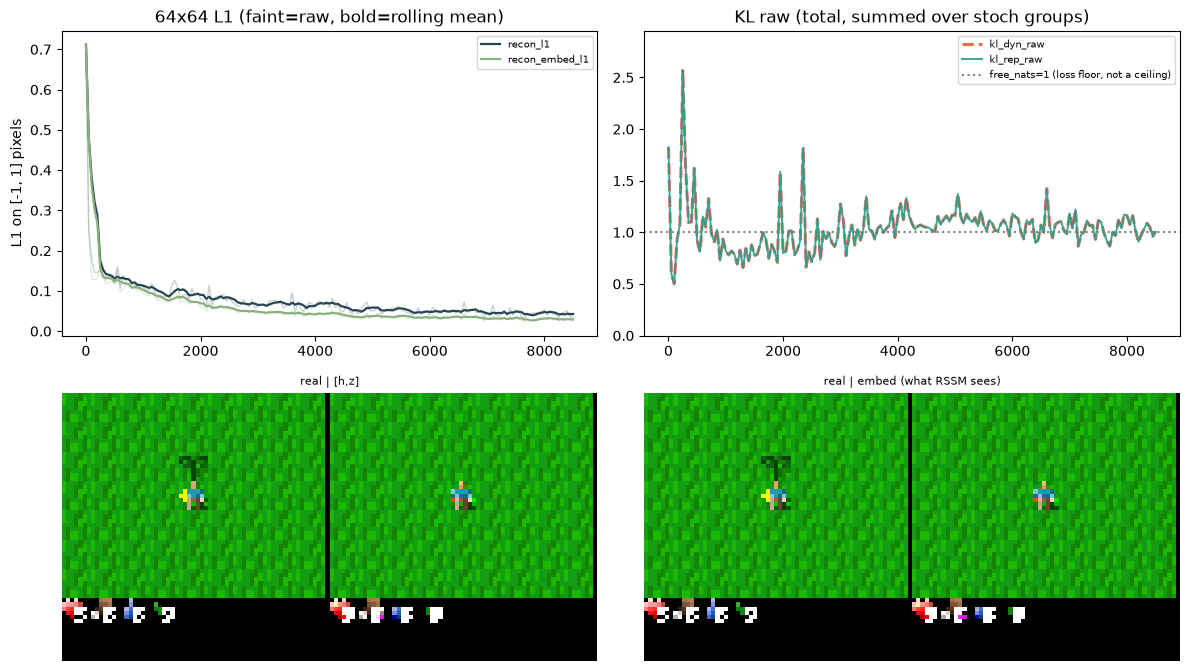

step  8500/12000  recon_l1=0.0351 emb_l1=0.0246 grad=0.0000  kl_raw=1.006/1.006 (dyn==rep, overlap is normal)  vram 10.0/10.8 GiB
  scaled contributions to total: recon=0.176 recon_embed=0.123 recon_bottleneck=0.000 recon_map=0.160 recon_blob=0.000 recon_embed_blob=0.000 recon_avatar=0.000 recon_embed_avatar=0.000 recon_hud=0.000 recon_embed_hud=0.000 grad=0.000 reward=0.013 continue=0.000 kl=0.824  | free_nats=1
  recon trend: last 500 steps avg=0.0420 vs prior 500 steps avg=0.0440 (+4.5%)


In [ ]:
log_dir = Path(train_cfg["log_dir"])
ckpt_dir = Path(train_cfg["checkpoint_dir"])
results_dir = Path(train_cfg["results_dir"])
for p in (log_dir, ckpt_dir, results_dir):
    p.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(log_dir))

steps = int(STEPS_OVERRIDE) if STEPS_OVERRIDE is not None else int(train_cfg["steps"])
batch_size = int(train_cfg["batch_size"])
seq_len = int(train_cfg["seq_len"])
log_every = int(train_cfg["log_every"])
image_every = int(train_cfg["image_every"])
ckpt_every = int(train_cfg["checkpoint_every"])

import time

history: list[dict] = []
last_recon_vis = None
steps_per_sec = None
last_log_time = time.time()
last_log_step = start_step


def show_progress(history, recon_vis, steps_per_sec=None):
    # wait=False: wait=True blocks the kernel until the notebook UI has
    # rendered the figure. After ~8k steps of 4-panel matplotlib that queue
    # backs up and training looks frozen (GPU 1%, VRAM still allocated).
    clear_output(wait=False)
    xs = [h["step"] for h in history]
    fig = plt.figure(figsize=(12, 7))
    ax0 = fig.add_subplot(2, 2, 1)
    # Plot each term's ACTUAL contribution to `total` (i.e. multiplied by its
    # own *_scale). `kl` already bakes in dyn_scale/rep_scale internally, so
    # comparing it directly against unscaled recon/recon_embed made recon look
    # negligible even when it was contributing just as much to the real total.
    scales = {
        "recon": float(train_cfg["recon_scale"]),
        "recon_embed": float(train_cfg.get("recon_embed_scale", 1.0)),
        "recon_bottleneck": float(train_cfg.get("recon_bottleneck_scale", 0.0)),
        "recon_map": float(train_cfg.get("recon_map_scale", 0.0)),
        "recon_blob": float(train_cfg.get("recon_blob_scale", 0.0)),
        "recon_embed_blob": float(train_cfg.get("recon_blob_scale", 0.0)),
        "recon_avatar": float(train_cfg.get("recon_avatar_scale", 0.0)),
        "recon_embed_avatar": float(train_cfg.get("recon_avatar_scale", 0.0)),
        "recon_hud": float(train_cfg.get("recon_hud_scale", 0.0)),
        "recon_embed_hud": float(train_cfg.get("recon_hud_scale", 0.0)),
        "grad": float(train_cfg.get("grad_scale", 0.0)),
        "reward": float(train_cfg["reward_scale"]),
        "continue": float(train_cfg["continue_scale"]),
        "kl": float(train_cfg["kl_scale"]),
    }
    def rolling_mean(values: list[float], window: int = 5) -> list[float]:
        out = []
        for i in range(len(values)):
            lo = max(0, i - window + 1)
            out.append(sum(values[lo : i + 1]) / (i - lo + 1))
        return out

    for key, color in [
        ("recon_l1", "#264653"),
        ("recon_embed_l1", "#8ab17d"),
        ("recon_blob", "#e76f51"),
        ("recon_embed_blob", "#f4a261"),
        ("recon_avatar", "#2a9d8f"),
        ("recon_hud", "#6d597a"),
    ]:
        if key not in ("recon_l1", "recon_embed_l1") and scales.get(key, 0.0) == 0.0:
            continue
        fallback = key.replace("_l1", "")
        raw = [h.get(key, h.get(fallback, 0.0)) for h in history]
        # Each point is a single minibatch's loss, so the
        # raw curve is noisy even while the underlying trend is improving. Plot
        # the noisy trace faint + a rolling mean on top so the trend is legible.
        ax0.plot(xs, raw, color=color, alpha=0.25, linewidth=1)
        ax0.plot(xs, rolling_mean(raw), label=key, color=color, linewidth=1.6)
    ax0.set_title("64x64 L1 (faint=raw, bold=rolling mean)")
    ax0.set_ylabel("L1 on [-1, 1] pixels")
    ax0.legend(fontsize=7)

    ax1 = fig.add_subplot(2, 2, 2)
    dyn_ys = [h["kl_dyn_raw"] for h in history]
    rep_ys = [h["kl_rep_raw"] for h in history]
    # These two are often numerically identical (same categorical KL, just
    # opposite .detach() sides for the gradient). Plotting solid-on-solid then
    # hides the first series completely -- which is why "kl_dyn_raw" looked
    # missing. Draw dyn as a thicker dashed line underneath, rep solid on top,
    # so both stay legible even when they overlap.
    ax1.plot(xs, dyn_ys, label="kl_dyn_raw", color="#e76f51", ls="--", linewidth=2.2, zorder=2)
    ax1.plot(xs, rep_ys, label="kl_rep_raw", color="#2a9d8f", ls="-", linewidth=1.4, zorder=3, alpha=0.9)
    # This is a MINIMUM the KL gets no penalty for staying at/below, not a target
    # it needs to cross -- see DreamerV3 paper eq. 5: max(1, KL) exists precisely
    # to switch the KL loss off once already small, not to pull it upward.
    free_nats = float(train_cfg["free_nats"])
    ax1.axhline(
        free_nats, color="gray", ls=":", linewidth=1.5,
        label=f"free_nats={free_nats:g} (loss floor, not a ceiling)",
    )
    # Keep the floor readable: don't let a single resume spike blow the y-axis
    # up so the free_nats line sits on the ceiling and the real signal looks flat.
    data_max = max(dyn_ys + rep_ys + [0.0])
    ax1.set_ylim(0.0, max(free_nats * 1.25, min(data_max * 1.15, free_nats * 4.0), 1.0))
    ax1.set_title("KL raw (total, summed over stoch groups)")
    ax1.legend(fontsize=7)

    if recon_vis is not None:
        real, pred_hz, pred_emb = recon_vis
        panels = [
            ("[h,z]", pred_hz),
            ("embed (what RSSM sees)", pred_emb),
        ]
        for i, (label, pred) in enumerate(panels):
            ax = fig.add_subplot(2, 2, 3 + i)
            ax.imshow(np.concatenate([real[0].numpy(), pred[0].numpy()], axis=1))
            ax.set_title(f"real | {label}", fontsize=8)
            ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    plt.close("all")
    h = history[-1]
    sps = f" ({steps_per_sec:.2f} steps/s)" if steps_per_sec else ""
    vram = vram_peak_gb()
    vram_s = f"  vram {vram[0]:.1f}/{vram[1]:.1f} GiB" if vram else ""
    contrib_str = " ".join(f"{k}={h.get(k, 0.0) * scales[k]:.3f}" for k in scales)
    same = abs(h["kl_dyn_raw"] - h["kl_rep_raw"]) < 1e-4
    recon_l1 = h.get("recon_l1", h["recon"])
    emb_l1 = h.get("recon_embed_l1", h["recon_embed"])
    print(
        f"step {h['step']:5d}/{steps}  "
        f"recon_l1={recon_l1:.4f} emb_l1={emb_l1:.4f} "
        f"grad={h['grad']:.4f}  "
        f"kl_raw={h['kl_dyn_raw']:.3f}/{h['kl_rep_raw']:.3f}"
        f"{' (dyn==rep, overlap is normal)' if same else ''}{sps}{vram_s}\n"
        f"  scaled contributions to total: {contrib_str}  | free_nats={free_nats:g}",
        flush=True,
    )
    # De-noise the "is it actually improving?" question: compare the mean of
    # the last chunk of logged points against the chunk before it, instead of
    # reading two single noisy points off the chart.
    n = len(history)
    chunk = max(1, min(10, n // 2))
    if n >= 2 * chunk:
        recent = sum(x.get("recon_l1", x["recon"]) for x in history[-chunk:]) / chunk
        prior = sum(x.get("recon_l1", x["recon"]) for x in history[-2 * chunk : -chunk]) / chunk
        pct = 100.0 * (1.0 - recent / max(prior, 1e-8))
        window_steps = chunk * log_every
        print(
            f"  recon trend: last {window_steps} steps avg={recent:.4f} vs "
            f"prior {window_steps} steps avg={prior:.4f} ({pct:+.1f}%)",
            flush=True,
        )


model.train()
print(f"training to step {steps} on {device} (start={start_step})...", flush=True)
for step in range(start_step + 1, steps + 1):
    batch = buffer.sample(batch_size, seq_len)
    _loss, metrics = world_model_step(
        model,
        optim,
        batch,
        device=device,
        train_cfg=train_cfg,
        amp_dtype=amp_dtype,
        scaler=scaler,
    )
    metrics["step"] = step

    if step % log_every == 0 or step == start_step + 1:
        for k, v in metrics.items():
            if k != "step":
                writer.add_scalar(f"m3/{k}", v, step)
        history.append(metrics)
        now = time.time()
        steps_per_sec = (step - last_log_step) / max(now - last_log_time, 1e-6)
        last_log_time, last_log_step = now, step
        # Dashboard is drawn after the image update below when both fire
        # on the same step, so we don't call show_progress twice (the
        # second IPython display is what wedged the kernel at 8500).
        if step % image_every != 0 and step != start_step + 1:
            show_progress(history, last_recon_vis, steps_per_sec)

    if step % image_every == 0 or step == start_step + 1:
        model.eval()
        with torch.no_grad(), autocast_context(device, amp_dtype):
            vis = buffer.sample(min(4, batch_size), seq_len)
            vis_g = to_device(vis, device)
            v_out = model(vis_g["obs"], vis_g["actions"])
            t_vis = seq_len // 2
            real = vis["obs"][:, t_vis].cpu()
            pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, t_vis].detach().cpu())
            pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, t_vis].detach().cpu())
            last_recon_vis = (real, pred_hz, pred_emb)
            from PIL import Image

            strips = [
                np.concatenate(
                    [real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()],
                    axis=1,
                )
                for i in range(real.shape[0])
            ]
            Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(
                results_dir / f"recon_step_{step:05d}.png"
            )
        model.train()
        if history:
            show_progress(history, last_recon_vis, steps_per_sec if step == last_log_step else None)

    if step % ckpt_every == 0:
        path = ckpt_dir / f"ckpt_step_{step:05d}.pt"
        torch.save({"step": step, "model": model.state_dict(), "optim": optim.state_dict()}, path)
        print(f"wrote {path}", flush=True)

final = ckpt_dir / "ckpt_final.pt"
torch.save({"step": steps, "model": model.state_dict(), "optim": optim.state_dict()}, final)
(results_dir / "train_metrics.json").write_text(json.dumps(history, indent=2))
writer.flush(); writer.close()
show_progress(history, last_recon_vis)

# Definitive end-of-run grid (larger batch, holdout-ish sample) for the README-style
# before/after comparison, independent of whatever image_every last landed on.
model.eval()
with torch.no_grad(), autocast_context(device, amp_dtype):
    vis = buffer.sample(8, seq_len)
    vis_g = to_device(vis, device)
    v_out = model(vis_g["obs"], vis_g["actions"])
    real = vis["obs"][:, -1].cpu()
    pred_hz = nchw_float_to_nhwc_uint8(v_out.recon[:, -1].detach().cpu())
    pred_emb = nchw_float_to_nhwc_uint8(v_out.recon_embed[:, -1].detach().cpu())
    from PIL import Image

    # Column order: real | [h,z] | embed (what the RSSM actually sees).
    strips = [
        np.concatenate(
            [real[i].numpy(), pred_hz[i].numpy(), pred_emb[i].numpy()],
            axis=1,
        )
        for i in range(real.shape[0])
    ]
    Image.fromarray(np.concatenate(strips, axis=0), mode="RGB").save(results_dir / "recon_final.png")
model.train()
print("done", final)


## Exit criteria — did this run actually work?

A healthy M3 run should show all of the following. This cell checks them
automatically instead of relying on eyeballing the curves.

**Important caveat, learned the hard way:** the pixel-std check below only
measures *aggregate* variance -- it cannot tell whether that variance is in
the right place. A model that nails big-block background color (grass green
vs. cave gray) while completely dropping every small object -- HUD digits,
mobs, trees, precise player pose -- can still pass every check here, because
those details are a tiny fraction of the frame's 4096 pixels and barely move
an aggregate loss/variance number either way. **Always look at
`recon_final.png` yourself; don't trust this cell alone for visual quality.**

What this cell (and M3's actual documented exit criteria in `milestones.md`)
*does* verify is the thing M3 is actually about: loss terms decreasing, KL
neither dead nor exploded, and reward predictions correlating with real
reward -- i.e. whether the compact `[h,z]` latent is control-useful, which is
the point of a world model. Photorealistic-looking reconstruction of every
mob and tree is a much harder, open-ended target that isn't part of that bar
(and isn't how any published Dreamer result on Crafter looks either) --
treat the recon panel as a *diagnostic* (is the latent dead? did the decoder
collapse?), not a pass/fail quality gate on its own.

In [ ]:
assert len(history) >= 2, "need at least two logged points to judge a trend"

first, last = history[0], history[-1]
checks: list[tuple[str, bool, str]] = []


def pct_drop(key: str) -> float:
    fallback = key.replace("_l1", "") if key.endswith("_l1") else key
    a = first.get(key, first.get(fallback, 0.0))
    b = last.get(key, last.get(fallback, 0.0))
    return 1.0 - (b / max(a, 1e-8))


for key, min_drop in [("recon_l1", 0.5), ("recon_embed_l1", 0.5)]:
    drop = pct_drop(key)
    fallback = key.replace("_l1", "")
    a = first.get(key, first.get(fallback, 0.0))
    b = last.get(key, last.get(fallback, 0.0))
    checks.append(
        (
            f"{key} loss dropped >= {min_drop:.0%} (first={a:.4f} -> last={b:.4f}, "
            f"actual={drop:.0%})",
            drop >= min_drop,
            "recon isn't improving — check lr, recon_scale, or a decoder/data bug",
        )
    )

# kl_dyn_raw is the TOTAL KL of the latent (summed over stoch groups).
# free_nats is a floor on the *loss* (max(KL, 1)), not a ceiling on the
# value. The 8k-step run that reconstructed terrain lived at 1.07-1.16
# for thousands of steps. Failure modes: collapse toward ~0, or tens of nats.
kl_dyn_last = last["kl_dyn_raw"]
checks.append(
    (
        f"kl_dyn_raw isn't dead (last={kl_dyn_last:.3f} > 0.02)",
        kl_dyn_last > 0.02,
        "posterior has collapsed onto the prior -- latent carries ~no information",
    )
)
checks.append(
    (
        f"kl_dyn_raw hasn't exploded (last={kl_dyn_last:.3f} < 30.0)",
        kl_dyn_last < 30.0,
        "posterior is ignoring the prior entirely -- imagination rollouts will drift badly",
    )
)

# Pixel-collapse check: decoder output std should be in the same ballpark as
# real-image std, not near zero (solid color).
model.eval()
with torch.no_grad(), autocast_context(device, amp_dtype):
    vis = buffer.sample(8, seq_len)
    vis_g = to_device(vis, device)
    v_out = model(vis_g["obs"], vis_g["actions"])
    obs_f = nhwc_uint8_to_nchw_float(vis_g["obs"])
    obs_std = float(obs_f.std())
    recon_std = float(v_out.recon.float().std())
    embed_std = float(v_out.recon_embed.float().std())
model.train()

for name, std in [
    ("recon", recon_std),
    ("recon_embed", embed_std),
]:
    ratio = std / max(obs_std, 1e-8)
    checks.append(
        (
            f"{name} pixel std is close to real ({name}_std={std:.4f} vs obs_std={obs_std:.4f}, "
            f"ratio={ratio:.2f})",
            ratio > 0.4,
            f"{name} has collapsed toward a constant (solid-color) output -- NOTE: this "
            "only checks aggregate variance, not whether it's in the right place. Nailing "
            "background color while dropping every small object (HUD digits, mobs, trees, "
            "precise player pose) still passes this check -- eyeball recon_final.png too.",
        )
    )

# M3's actual documented exit criterion (milestones.md): reward prediction
# CORRELATES with real reward on held-out sequences -- this is what tests
# whether the latent is control-useful, independent of pixel fidelity.
true_chunks, pred_chunks = [], []
with torch.no_grad(), autocast_context(device, amp_dtype):
    for _ in range(20):
        rb = buffer.sample(batch_size, seq_len)
        rb_g = to_device(rb, device)
        r_out = model(rb_g["obs"], rb_g["actions"])
        true_chunks.append(rb["rewards"].numpy().reshape(-1))
        pred_chunks.append(r_out.reward_pred.squeeze(-1).float().cpu().numpy().reshape(-1))
reward_true = np.concatenate(true_chunks)
reward_pred = np.concatenate(pred_chunks)
if reward_true.std() > 1e-8 and reward_pred.std() > 1e-8:
    reward_corr = float(np.corrcoef(reward_true, reward_pred)[0, 1])
    checks.append(
        (
            f"reward prediction correlates with real reward (r={reward_corr:.2f})",
            reward_corr > 0.3,
            "reward head isn't tracking real reward -- latent may not be carrying "
            "reward-relevant information",
        )
    )
else:
    print("[SKIP] reward correlation: too few nonzero-reward examples in this sample")

print(f"steps trained: {last['step']}\n")
all_pass = True
for description, ok, hint in checks:
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {description}")
    if not ok:
        print(f"       -> {hint}")
        all_pass = False

print()
print("RESULT:", "PASS — M3 world model looks healthy" if all_pass else "FAIL — see hints above")
